# AI2 HW2 - Phase 10: DeBERTa ml=512 seed=42 (leaderboard breakthrough)

**If you see this, you have the correct notebook version.**

Current Kaggle: #29 @ 0.68 (α-weighted 3-seed DeBERTa ensemble, val 0.7070).
Target: top 10 requires ~0.71 test. Cross-model ensemble (DistilBERT/BERT + DeBERTa) explored locally - α-optimizer collapses to 100% DeBERTa. Weaker models can't complement DeBERTa's CR↔AMB errors.

Path forward: scale DeBERTa-internal diversity, not cross-family.

Phase 10: DeBERTa @ ml=512 (vs trained 256). DeBERTa-v3-base supports 512 natively. If answers are being truncated at 256, this is a free gain. Also produces a 4th DeBERTa checkpoint to add to the α-ensemble.

Single run: **DeBERTa, ml=512, seed=42, ep=3, lr=2e-5, wd=0.0, two_segment**.

- Pass: val_f1_macro > 0.6962 (baseline seed=42 @ ml=256) → queue seeds 0, 1 next.
- Plateau/regress: means truncation isn't the bottleneck; skip to NEG or two-stage.

---

In [37]:
# Cell 1 - Install dependencies
import subprocess, sys

# Pin transformers to 4.44.0 - transformers 5.0.0 has a broken DeBERTa-v3 fine-tuning issue.
# After this install, the kernel MUST be restarted before running Cell 2+.
# On Kaggle: Run this cell alone first -> Restart kernel -> Run all remaining cells.
# spaCy + en_core_web_sm χρειάζονται μόνο αν τρέξω cfg.use_negation_markers=True.
result = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "transformers==4.44.0", "datasets", "accelerate", "scikit-learn",
    "sentencepiece", "protobuf", "spacy"], capture_output=True, text=True)
print(result.stdout[-500:] if result.stdout else "")
print(result.stderr[-300:] if result.stderr else "")

# Download spaCy model (small, ~13MB) - αν αποτύχει (π.χ. internet off) τα negation experiments θα σκάσουν
spacy_result = subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
                              capture_output=True, text=True)
print(spacy_result.stdout[-200:] if spacy_result.stdout else "")
print(spacy_result.stderr[-200:] if spacy_result.stderr else "")

import transformers
print(f"transformers version: {transformers.__version__}")
assert transformers.__version__.startswith("4."), \
    f"STOP: transformers is {transformers.__version__}. Restart the kernel and re-run."
print("deps ok")




 you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


transformers version: 4.44.0
deps ok


In [38]:
# Cell 2 - Library (inlined src/) - auto-generated by scripts/build_library_cell.py
# ============================================================
# ============================================================
# src/config.py
# ============================================================
from dataclasses import dataclass, field, asdict
from typing import Literal
import json


@dataclass
class ExperimentConfig:
    # --- model ---
    model_name: str = "distilbert-base-uncased"

    # --- input ---
    input_fmt: Literal["two_segment", "concat_sep"] = "two_segment"
    max_length: int = 128
    # Αν True, προσθέτω [AFFIRM_Q] και [MULTI_Q] special tokens στην αρχή του
    # question string, based on dataset booleans. Ο model καλεί resize_token_embeddings.
    use_question_tokens: bool = False
    # Αν True, προσθέτω [NEG] token πριν από negated verbs στα answers (spaCy parse).
    use_negation_markers: bool = False

    # --- training ---
    lr: float = 2e-5
    batch_size: int = 32
    epochs: int = 3
    warmup_steps: int = 0
    grad_clip: float = 1.0

    # --- class imbalance ---
    use_class_weights: bool = False

    # --- loss ---
    # "ce" = standard cross-entropy
    # "focal" = focal loss με focusing parameter gamma
    loss: Literal["ce", "focal"] = "ce"
    focal_gamma: float = 2.0

    # --- training target ---
    # "clarity" = κλασικό 3-class training
    # "evasion" = training σε 9 classes, mapping σε 3 στο eval via taxonomy
    train_target: Literal["clarity", "evasion"] = "clarity"

    # --- multi-task auxiliary evasion loss ---
    # > 0 ενεργοποιεί dual-head multi-task model: primary=clarity (3-class),
    # auxiliary=evasion (9-class), combined loss = CE_clarity + λ * CE_evasion.
    # Mutually exclusive με train_target="evasion". 0.0 απενεργοποιεί.
    aux_evasion_weight: float = 0.0

    # --- reproducibility ---
    seed: int = 42
    split_id: int = 0

    # --- run mode ---
    mode: Literal["smoke", "dev", "confirm", "final"] = "dev"
    smoke_n: int = 50  # samples per class in smoke mode

    # --- paths ---
    data_dir: str = "data"
    models_dir: str = "models"

    # derived fields (not constructor args)
    run_id: str = field(init=False)

    def __post_init__(self):
        short_model = self.model_name.split("/")[-1]
        cw_tag = "_cw" if self.use_class_weights else ""
        target_tag = "" if self.train_target == "clarity" else f"_tgt{self.train_target}"
        loss_tag = "" if self.loss == "ce" else f"_focal{self.focal_gamma}"
        qtok_tag = "_qtoks" if self.use_question_tokens else ""
        neg_tag = "_neg" if self.use_negation_markers else ""
        aux_tag = f"_aux{self.aux_evasion_weight}" if self.aux_evasion_weight > 0 else ""
        self.run_id = (
            f"{short_model}_{self.input_fmt}_lr{self.lr}_bs{self.batch_size}"
            f"_ep{self.epochs}_ml{self.max_length}_seed{self.seed}"
            f"{cw_tag}{target_tag}{loss_tag}{qtok_tag}{neg_tag}{aux_tag}"
        )

    def to_dict(self) -> dict:
        return asdict(self)

    def save(self, path: str) -> None:
        with open(path, "w") as f:
            json.dump(self.to_dict(), f, indent=2)

    @classmethod
    def load(cls, path: str) -> "ExperimentConfig":
        with open(path) as f:
            d = json.load(f)
        d.pop("run_id", None)
        return cls(**d)

# ============================================================
# src/data.py
# ============================================================
from typing import Optional, Tuple

import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split

# Clarity level (3 classes) - το required output του assignment
CLARITY_LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
CLARITY2ID = {l: i for i, l in enumerate(CLARITY_LABELS)}
ID2CLARITY = {i: l for l, i in CLARITY2ID.items()}
NUM_CLARITY = 3

# Evasion level (9 classes) - fine-grained taxonomy από το paper
EVASION_LABELS = [
    "Explicit",
    "Implicit",
    "General",
    "Partial/half-answer",
    "Dodging",
    "Deflection",
    "Declining to answer",
    "Claims ignorance",
    "Clarification",
]
EVASION2ID = {l: i for i, l in enumerate(EVASION_LABELS)}
ID2EVASION = {i: l for l, i in EVASION2ID.items()}
NUM_EVASION = 9

# Deterministic mapping από το dataset paper (arxiv 2409.13879)
EVASION_TO_CLARITY = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "General": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Dodging": "Ambivalent",
    "Deflection": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply",
}
EVASION_ID_TO_CLARITY_ID = {
    EVASION2ID[e]: CLARITY2ID[EVASION_TO_CLARITY[e]] for e in EVASION_LABELS
}

# Backward compat - default είναι clarity
LABEL2ID = CLARITY2ID
ID2LABEL = ID2CLARITY
NUM_LABELS = NUM_CLARITY

HF_DATASET = "ailsntua/QEvasion"


def load_clarity(data_dir: Optional[str] = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load QEvasion από Hugging Face (όπως στο HW1). Κάνω rename στο boundary:
    `interview_answer` -> `answer`, `clarity_label` -> `label`. Το `question` και
    το `evasion_label` μένουν ως είναι (το evasion_label χρειάζεται για το
    evasion-based training experiment).
    """
    ds = load_dataset(HF_DATASET)
    train = ds["train"].to_pandas().copy()
    test = ds["test"].to_pandas().copy()
    for df in (train, test):
        df.rename(
            columns={"interview_answer": "answer", "clarity_label": "label"},
            inplace=True,
        )
    return train, test


# Rows με visibly corrupted answer text, εντοπισμένα στην ανάλυση του HW1
# μέσω OOV-based inspection. Αφαιρούμε by `index` column του dataset.
CORRUPTED_TRAIN_INDEX_VALUES = list(range(1870, 1884))  # 1870..1883 inclusive (14 rows)


def clean_data(df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
    """Forum-literal ordering:
    1. Conflicts detected στο RAW set — drop ΟΛΑ τα rows κάθε conflicting (q,a) pair
       (και τα δύο σκέλη, ακόμα κι αν το ένα τυχαίνει να είναι corrupted).
    2. Drop τα εναπομείναντα corrupted rows (index ∈ [1870, 1883]) από το HW1 OOV analysis.
    Expected: 3448 -> 3424 (−24 conflicts) -> 3410 (−14 corrupted, αν δεν υπάρχει overlap
    με τα ήδη-dropped conflict rows).
    """
    raw_n = len(df)
    qa_cols = ["question", "answer"]

    dup_mask = df.duplicated(subset=qa_cols, keep=False)
    conflicting_ids = (
        df[dup_mask]
        .groupby(qa_cols)["label"]
        .nunique()
        .pipe(lambda s: s[s > 1])
        .index
    )
    multi_idx = pd.MultiIndex.from_frame(df[qa_cols])
    conflict_multi = pd.MultiIndex.from_tuples(conflicting_ids)
    drop_mask = multi_idx.isin(conflict_multi)
    cleaned = df[~drop_mask].copy()
    after_conflicts = len(cleaned)

    cleaned = cleaned.loc[~cleaned["index"].isin(CORRUPTED_TRAIN_INDEX_VALUES)].reset_index(drop=True)
    after_corrupted = len(cleaned)

    if verbose:
        print(
            f"[clean_data] raw={raw_n} "
            f"-> after_conflicts={after_conflicts} (−{raw_n - after_conflicts}) "
            f"-> after_corrupted={after_corrupted} (−{after_conflicts - after_corrupted})"
        )
    return cleaned


def encode_labels(df: pd.DataFrame, label_col: str = "label") -> pd.DataFrame:
    """Κάνω encode και τα clarity labels (`label` -> `label_id`) και τα evasion
    labels (`evasion_label` -> `evasion_id`), αν υπάρχουν. Το evasion_id το
    χρειάζομαι για το evasion-based training experiment όπου κάνω train σε 9
    classes και mapping πίσω σε 3 στο eval time.
    """
    df = df.copy()
    df["label_id"] = df[label_col].map(LABEL2ID)
    if "evasion_label" in df.columns:
        df["evasion_id"] = df["evasion_label"].map(EVASION2ID)
    return df


def create_split(
    df: pd.DataFrame,
    val_size: float = 0.1,
    seed: int = 0,
) -> Tuple[np.ndarray, np.ndarray]:
    """Επιστρέφει (train_indices, val_indices) — fixed split για fair comparison."""
    idx = np.arange(len(df))
    train_idx, val_idx = train_test_split(
        idx,
        test_size=val_size,
        random_state=seed,
        stratify=df["label_id"].values,
    )
    return train_idx, val_idx


def subgroup_metadata(df: pd.DataFrame) -> pd.DataFrame:
    """Προσθέτει q_len_bin και a_len_bin για subgroup analysis."""
    df = df.copy()
    df["q_len"] = df["question"].str.split().str.len()
    df["a_len"] = df["answer"].str.split().str.len()
    df["q_len_bin"] = pd.qcut(df["q_len"], q=3, labels=["short", "medium", "long"])
    df["a_len_bin"] = pd.qcut(df["a_len"], q=3, labels=["short", "medium", "long"])
    return df


def smoke_subset(df: pd.DataFrame, n_per_class: int = 50, seed: int = 42) -> pd.DataFrame:
    """Μικρό subset για smoke testing — n δείγματα ανά κλάση."""
    parts = [
        g.sample(min(n_per_class, len(g)), random_state=seed)
        for _, g in df.groupby("label_id")
    ]
    return pd.concat(parts, ignore_index=True)

# ============================================================
# src/tokenization.py
# ============================================================
import pandas as pd
import torch
from torch.utils.data import TensorDataset
from transformers import PreTrainedTokenizerBase

QUESTION_SPECIAL_TOKENS = ["[AFFIRM_Q]", "[MULTI_Q]"]
NEGATION_SPECIAL_TOKEN = "[NEG]"


def ensure_special_tokens(tokens: list, tokenizer, model) -> int:
    """Προσθέτω tokens στο tokenizer vocab και κάνω resize τα model embeddings.
    Επιστρέφω πόσα νέα tokens προστέθηκαν.
    """
    added = tokenizer.add_special_tokens({"additional_special_tokens": list(tokens)})
    if added > 0:
        model.resize_token_embeddings(len(tokenizer))
    return added


def add_question_special_tokens(tokenizer, model) -> int:
    return ensure_special_tokens(QUESTION_SPECIAL_TOKENS, tokenizer, model)


def build_question_prefix(row) -> str:
    """Φτιάχνω το prefix string από τα dataset booleans. Κενό string αν καμία flag."""
    parts = []
    if bool(row.get("multiple_questions", False)):
        parts.append("[MULTI_Q]")
    if bool(row.get("affirmative_questions", False)):
        parts.append("[AFFIRM_Q]")
    return " ".join(parts)


def apply_question_prefix(df: pd.DataFrame) -> pd.DataFrame:
    """Επιστρέφω αντίγραφο του df με prefix στο question column."""
    df = df.copy()
    prefixes = df.apply(build_question_prefix, axis=1)
    df["question"] = (prefixes + " " + df["question"].astype(str)).str.strip()
    return df


_spacy_nlp = None


def _get_spacy():
    """Lazy-load en_core_web_sm. Κάνω import spacy μόνο όταν χρειάζεται."""
    global _spacy_nlp
    if _spacy_nlp is None:
        import spacy
        try:
            _spacy_nlp = spacy.load("en_core_web_sm", disable=["ner"])
        except OSError as e:
            raise RuntimeError(
                "spaCy model 'en_core_web_sm' δεν είναι εγκατεστημένο. "
                "Εκτέλεσε: python -m spacy download en_core_web_sm"
            ) from e
    return _spacy_nlp


def mark_negations(text: str) -> str:
    """Προσθέτω [NEG] token πριν από verbs που έχουν negation dependent.
    Χρησιμοποιώ spaCy dependency parse. Αν το spacy model λείπει, πετάει error.
    """
    if not text:
        return text
    nlp = _get_spacy()
    doc = nlp(text)
    # indices των heads που έχουν neg dependent
    neg_heads = {tok.head.i for tok in doc if tok.dep_ == "neg"}
    if not neg_heads:
        return text
    pieces = []
    for tok in doc:
        if tok.i in neg_heads:
            pieces.append(f"{NEGATION_SPECIAL_TOKEN} {tok.text_with_ws}")
        else:
            pieces.append(tok.text_with_ws)
    return "".join(pieces)


def apply_negation_markers(df: pd.DataFrame, answer_col: str = "answer") -> pd.DataFrame:
    """Επιστρέφω αντίγραφο του df με [NEG] markers στα answers."""
    df = df.copy()
    df[answer_col] = df[answer_col].astype(str).map(mark_negations)
    return df


def tokenize_pairs(
    df: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str = "two_segment",
    label_col: str = "label_id",
) -> TensorDataset:
    """Tokenize Q+A pairs. Returns TensorDataset of (input_ids, attention_mask, labels).

    Το `label_col` επιλέγει τί στόχο βάζω στα labels: "label_id" για clarity
    3-class, "evasion_id" για evasion 9-class training.
    """
    questions = df["question"].astype(str).tolist()
    answers = df["answer"].astype(str).tolist()

    if input_fmt == "two_segment":
        enc = tokenizer(
            questions,
            answers,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
    elif input_fmt == "concat_sep":
        sep = tokenizer.sep_token or "[SEP]"
        texts = [f"{q} {sep} {a}" for q, a in zip(questions, answers)]
        enc = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
    else:
        raise ValueError(f"Unknown input_fmt: {input_fmt!r}")

    labels = torch.tensor(df[label_col].values, dtype=torch.long)
    return TensorDataset(enc["input_ids"], enc["attention_mask"], labels)


def tokenize_pairs_multitask(
    df: pd.DataFrame,
    tokenizer: PreTrainedTokenizerBase,
    max_length: int,
    input_fmt: str = "two_segment",
) -> TensorDataset:
    """Like tokenize_pairs αλλά επιστρέφει (input_ids, attention_mask, clarity_id, evasion_id).
    Για multi-task training με αυξιλιαρικό evasion head.
    """
    questions = df["question"].astype(str).tolist()
    answers = df["answer"].astype(str).tolist()

    if input_fmt == "two_segment":
        enc = tokenizer(
            questions, answers, padding="max_length", truncation=True,
            max_length=max_length, return_tensors="pt",
        )
    elif input_fmt == "concat_sep":
        sep = tokenizer.sep_token or "[SEP]"
        texts = [f"{q} {sep} {a}" for q, a in zip(questions, answers)]
        enc = tokenizer(
            texts, padding="max_length", truncation=True,
            max_length=max_length, return_tensors="pt",
        )
    else:
        raise ValueError(f"Unknown input_fmt: {input_fmt!r}")

    clarity = torch.tensor(df["label_id"].values, dtype=torch.long)
    evasion = torch.tensor(df["evasion_id"].values, dtype=torch.long)
    return TensorDataset(enc["input_ids"], enc["attention_mask"], clarity, evasion)

# ============================================================
# src/model.py
# ============================================================
from typing import Tuple

from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    PreTrainedModel,
    PreTrainedTokenizerBase,
)


def load_model_and_tokenizer(
    model_name: str,
    num_labels: int = 3,
) -> Tuple[PreTrainedModel, PreTrainedTokenizerBase]:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )
    return model, tokenizer

# ============================================================
# src/multitask.py
# ============================================================
"""Multi-task classifier: shared backbone + (clarity 3-class, evasion 9-class) heads.

Primary task = clarity. Evasion head ενεργοποιείται μόνο στο training ως auxiliary loss,
δίνοντας στο backbone fine-grained supervision. Στο eval, χρησιμοποιείται μόνο το clarity head.
"""

from dataclasses import dataclass
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer


@dataclass
class MultiTaskOutput:
    logits: torch.Tensor  # clarity logits (primary, used by evaluate)
    evasion_logits: torch.Tensor
    loss: Optional[torch.Tensor] = None
    clarity_loss: Optional[torch.Tensor] = None
    evasion_loss: Optional[torch.Tensor] = None


class MultiTaskClassifier(nn.Module):
    """Shared backbone + two linear heads. Pool [CLS] από last_hidden_state.

    Για DeBERTa χρησιμοποιούμε τον built-in ContextPooler όταν διαθέσιμος, αλλιώς
    πέφτουμε σε [CLS] hidden state. Το resize_token_embeddings κάνει passthrough
    στο backbone.
    """

    def __init__(
        self,
        model_name: str,
        num_clarity: int = 3,
        num_evasion: int = 9,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.config = AutoConfig.from_pretrained(model_name)
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden = self.config.hidden_size
        # Shared pre-classifier to mimic DistilBertForSequenceClassification's head:
        # Linear(hidden, hidden) -> ReLU -> Dropout -> head.
        # Without this, the multi-task model has a thinner head than the baseline
        # and confounds any comparison against single-task DistilBert.
        self.pre_classifier = nn.Linear(hidden, hidden)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.clarity_head = nn.Linear(hidden, num_clarity)
        self.evasion_head = nn.Linear(hidden, num_evasion)

    def _pool(self, outputs) -> torch.Tensor:
        # HF models expose pooler_output for BERT/DeBERTa; DistilBERT doesn't.
        pooled = getattr(outputs, "pooler_output", None)
        if pooled is None:
            pooled = outputs.last_hidden_state[:, 0]
        return pooled

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        labels: Optional[torch.Tensor] = None,
        evasion_labels: Optional[torch.Tensor] = None,
        aux_weight: float = 0.3,
    ) -> MultiTaskOutput:
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self._pool(outputs)
        pooled = self.pre_classifier(pooled)
        pooled = self.activation(pooled)
        pooled = self.dropout(pooled)
        clarity_logits = self.clarity_head(pooled)
        evasion_logits = self.evasion_head(pooled)

        loss = clarity_loss = evasion_loss = None
        if labels is not None:
            clarity_loss = F.cross_entropy(clarity_logits, labels)
            loss = clarity_loss
            if evasion_labels is not None and aux_weight > 0:
                evasion_loss = F.cross_entropy(evasion_logits, evasion_labels)
                loss = clarity_loss + aux_weight * evasion_loss

        return MultiTaskOutput(
            logits=clarity_logits,
            evasion_logits=evasion_logits,
            loss=loss,
            clarity_loss=clarity_loss,
            evasion_loss=evasion_loss,
        )

    def resize_token_embeddings(self, new_size: int):
        return self.backbone.resize_token_embeddings(new_size)


def load_multitask_model(
    model_name: str,
    num_clarity: int = 3,
    num_evasion: int = 9,
    dropout: float = 0.1,
):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = MultiTaskClassifier(
        model_name,
        num_clarity=num_clarity,
        num_evasion=num_evasion,
        dropout=dropout,
    )
    return model, tokenizer

# ============================================================
# src/train.py
# ============================================================
import random
from typing import Optional

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def focal_loss(
    logits: torch.Tensor,
    labels: torch.Tensor,
    gamma: float = 2.0,
    class_weights: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    """Multiclass focal loss. Down-weights well-classified examples με factor
    (1 - p_t)^gamma. Παράγει ίδιο mean reduction με cross_entropy.
    """
    ce = F.cross_entropy(logits, labels, weight=class_weights, reduction="none")
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()


def train_one_epoch(
    model,
    loader: DataLoader,
    optimizer,
    scheduler,
    device,
    grad_clip: float = 1.0,
    class_weights: Optional[torch.Tensor] = None,
    loss_type: str = "ce",
    focal_gamma: float = 2.0,
    aux_evasion_weight: float = 0.0,
) -> float:
    """Κάθε batch είναι (input_ids, attn, labels) ή (input_ids, attn, clarity, evasion)
    για multi-task. Το multi-task μονοπάτι ενεργοποιείται μόνο όταν
    len(batch)==4 και aux_evasion_weight>0 - τότε `model` πρέπει να είναι
    MultiTaskClassifier που δέχεται evasion_labels.
    """
    model.train()
    use_ce_weight = class_weights is not None
    total_loss = 0.0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        optimizer.zero_grad()

        if len(batch) == 4 and aux_evasion_weight > 0:
            input_ids, attention_mask, labels, evasion_labels = batch
            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels,
                evasion_labels=evasion_labels,
                aux_weight=aux_evasion_weight,
            )
            loss = out.loss
        else:
            input_ids, attention_mask, labels = batch[:3]
            if loss_type == "focal":
                out = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = focal_loss(
                    out.logits, labels, gamma=focal_gamma, class_weights=class_weights
                )
            elif use_ce_weight:
                out = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = F.cross_entropy(out.logits, labels, weight=class_weights)
            else:
                out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = out.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

# ============================================================
# src/evaluate.py
# ============================================================
from typing import Optional, Tuple

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader


def _softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


def _collapse_to_clarity(
    evasion_logits: np.ndarray, evasion_to_clarity: np.ndarray, num_clarity: int = 3
) -> np.ndarray:
    """Sum evasion softmax probs στις clarity classes που αντιστοιχούν.
    Επιστρέφει (N, num_clarity) probabilities (όχι logits).
    """
    probs = _softmax(evasion_logits, axis=-1)
    collapsed = np.zeros((probs.shape[0], num_clarity), dtype=probs.dtype)
    for e_id in range(probs.shape[1]):
        c_id = int(evasion_to_clarity[e_id])
        collapsed[:, c_id] += probs[:, e_id]
    return collapsed


@torch.no_grad()
def evaluate(
    model,
    loader: DataLoader,
    device,
    evasion_to_clarity: Optional[np.ndarray] = None,
) -> Tuple[dict, np.ndarray, np.ndarray]:
    """Evaluate. Αν δοθεί `evasion_to_clarity` (shape [NUM_EVASION]), ο model
    θεωρείται 9-class evasion classifier: κάνω collapse τα probs σε 3 clarity
    classes (sum probs) και τα labels από evasion_ids σε clarity_ids, ώστε όλες
    οι reported metrics να είναι στο 3-class clarity level (comparable με τα
    clarity-target runs). Το `val_loss` μένει το 9-class training loss.
    """
    model.eval()
    all_logits, all_labels = [], []
    total_loss = 0.0
    for batch in loader:
        batch = [b.to(device) for b in batch]
        input_ids, attention_mask, labels = batch[:3]
        out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        # out.loss μπορεί να είναι None (π.χ. multi-task forward χωρίς evasion_labels).
        if out.loss is not None:
            total_loss += out.loss.item()
        all_logits.append(out.logits.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

    logits = np.concatenate(all_logits, axis=0)
    labels_np = np.concatenate(all_labels, axis=0)

    if evasion_to_clarity is not None:
        clarity_probs = _collapse_to_clarity(logits, evasion_to_clarity, num_clarity=3)
        preds = clarity_probs.argmax(axis=1)
        labels_for_metrics = evasion_to_clarity[labels_np].astype(np.int64)
        # Σώζω log-probs ως "logits" ώστε downstream code (softmax-then-use) να
        # παράγει ξανά τα ίδια clarity_probs: softmax(log_probs) == probs (αφού
        # τα probs αθροίζουν ήδη σε 1).
        logits_out = np.log(np.clip(clarity_probs, 1e-12, None))
        labels_out = labels_for_metrics
    else:
        preds = logits.argmax(axis=1)
        labels_for_metrics = labels_np
        logits_out = logits
        labels_out = labels_np

    metrics = {
        "val_loss": total_loss / max(len(loader), 1),
        "accuracy": float(accuracy_score(labels_for_metrics, preds)),
        "f1_macro": float(
            f1_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "precision_macro": float(
            precision_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "recall_macro": float(
            recall_score(labels_for_metrics, preds, average="macro", zero_division=0)
        ),
        "f1_per_class": f1_score(
            labels_for_metrics, preds, average=None, labels=[0, 1, 2], zero_division=0
        ).tolist(),
    }
    return metrics, logits_out, labels_out

# ============================================================
# src/experiment.py
# ============================================================
import json
from pathlib import Path

import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler
from transformers import get_linear_schedule_with_warmup



from sklearn.utils.class_weight import compute_class_weight








def run_experiment(cfg: ExperimentConfig):
    """Επιστρέφει: (history, val_logits, val_labels, test_df, tokenizer, model, device).
    Το Cell 4 του notebook χρησιμοποιεί αυτό το 7-tuple για submission generation
    και GPU cleanup μεταξύ runs.
    """
    set_seed(cfg.seed)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[info] device: {device}")

    train_df, test_df = load_clarity(cfg.data_dir)
    cleaned = clean_data(train_df)
    cleaned = encode_labels(cleaned)
    print(f"[info] cleaned: {len(cleaned)} rows (original: {len(train_df)})")

    if cfg.mode == "smoke":
        cleaned = smoke_subset(cleaned, n_per_class=cfg.smoke_n, seed=cfg.seed)
        print(f"[info] smoke subset: {len(cleaned)} rows")

    train_idx, val_idx = create_split(cleaned, val_size=0.1, seed=cfg.split_id)
    train_df_split = cleaned.iloc[train_idx].reset_index(drop=True)
    val_df_split = cleaned.iloc[val_idx].reset_index(drop=True)
    print(f"[info] train: {len(train_df_split)}, val: {len(val_df_split)}")

    # Multi-task και evasion-target είναι mutually exclusive
    multitask = cfg.aux_evasion_weight > 0
    if multitask and cfg.train_target == "evasion":
        raise ValueError(
            "aux_evasion_weight>0 και train_target='evasion' είναι incompatible - "
            "το multi-task έχει ήδη evasion ως αυξιλιαρικό. Διάλεξε ένα."
        )

    # Train target: clarity (3-class) ή evasion (9-class, collapse σε 3 στο eval)
    if cfg.train_target == "evasion":
        num_labels = NUM_EVASION
        label_col = "evasion_id"
        evasion_to_clarity = np.array(
            [EVASION_ID_TO_CLARITY_ID[i] for i in range(NUM_EVASION)], dtype=np.int64
        )
        print(f"[info] train_target=evasion -> {NUM_EVASION}-class training, eval collapsed to 3 clarity classes")
    else:
        num_labels = NUM_CLARITY
        label_col = "label_id"
        evasion_to_clarity = None

    # Class weights (only on clarity target; για evasion δεν τα υπολογίζω στο 9-class)
    class_weights = None
    if cfg.use_class_weights and cfg.train_target == "clarity":
        weights = compute_class_weight(
            "balanced",
            classes=np.array([0, 1, 2]),
            y=train_df_split["label_id"].values,
        )
        class_weights = torch.tensor(weights, dtype=torch.float).to(device)
        print(
            f"[info] class weights: CR={weights[0]:.3f}  AMB={weights[1]:.3f}  CNR={weights[2]:.3f}"
        )

    if multitask:
        print(f"[info] multi-task mode: clarity head (3) + evasion head (9), aux_weight={cfg.aux_evasion_weight}")
        model, tokenizer = load_multitask_model(
            cfg.model_name, num_clarity=NUM_CLARITY, num_evasion=NUM_EVASION
        )
    else:
        model, tokenizer = load_model_and_tokenizer(cfg.model_name, num_labels=num_labels)
    model.to(device)

    extra_tokens = []
    if cfg.use_question_tokens:
        extra_tokens.extend(QUESTION_SPECIAL_TOKENS)
    if cfg.use_negation_markers:
        extra_tokens.append(NEGATION_SPECIAL_TOKEN)
    if extra_tokens:
        added = ensure_special_tokens(extra_tokens, tokenizer, model)
        print(f"[info] added {added} special tokens: {extra_tokens}")

    if cfg.use_question_tokens:
        train_df_split = apply_question_prefix(train_df_split)
        val_df_split = apply_question_prefix(val_df_split)
    if cfg.use_negation_markers:
        print("[info] applying spaCy negation markers to answers (train + val)")
        train_df_split = apply_negation_markers(train_df_split)
        val_df_split = apply_negation_markers(val_df_split)

    if multitask:
        train_ds = tokenize_pairs_multitask(
            train_df_split, tokenizer, cfg.max_length, cfg.input_fmt
        )
        val_ds = tokenize_pairs_multitask(
            val_df_split, tokenizer, cfg.max_length, cfg.input_fmt
        )
    else:
        train_ds = tokenize_pairs(
            train_df_split, tokenizer, cfg.max_length, cfg.input_fmt, label_col=label_col
        )
        val_ds = tokenize_pairs(
            val_df_split, tokenizer, cfg.max_length, cfg.input_fmt, label_col=label_col
        )
    train_loader = DataLoader(
        train_ds, batch_size=cfg.batch_size, sampler=RandomSampler(train_ds)
    )
    val_loader = DataLoader(
        val_ds, batch_size=cfg.batch_size, sampler=SequentialSampler(val_ds)
    )

    # DeBERTa-v3: give classifier+pooler head a 10x higher lr than the backbone.
    # The randomly-init head needs stronger signal; backbone gradients get clipped too
    # aggressively at uniform lr because DeBERTa's disentangled attention produces
    # large grad norms (max ~10) which clip=1.0 reduces 10x.
    if "deberta" in cfg.model_name.lower():
        if multitask:
            head_params = (
                list(model.pre_classifier.parameters())
                + list(model.clarity_head.parameters())
                + list(model.evasion_head.parameters())
            )
        else:
            head_params = list(model.pooler.parameters()) + list(model.classifier.parameters())
        head_ids = {id(p) for p in head_params}
        backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
        optimizer = AdamW([
            {"params": backbone_params, "lr": cfg.lr},
            {"params": head_params,     "lr": cfg.lr * 10},
        ], eps=1e-6)
    else:
        optimizer = AdamW(model.parameters(), lr=cfg.lr, eps=1e-6)
    total_steps = len(train_loader) * cfg.epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=cfg.warmup_steps,
        num_training_steps=total_steps,
    )

    run_dir = Path(cfg.models_dir) / cfg.run_id
    run_dir.mkdir(parents=True, exist_ok=True)

    history = []
    val_logits: np.ndarray = np.array([])
    val_labels: np.ndarray = np.array([])
    best_f1 = -1.0
    for epoch in range(cfg.epochs):
        train_loss = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            cfg.grad_clip,
            class_weights=class_weights,
            loss_type=cfg.loss,
            focal_gamma=cfg.focal_gamma,
            aux_evasion_weight=cfg.aux_evasion_weight,
        )
        val_metrics, val_logits, val_labels = evaluate(
            model, val_loader, device, evasion_to_clarity=evasion_to_clarity
        )
        print(
            f"[epoch {epoch+1}/{cfg.epochs}] "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['val_loss']:.4f} "
            f"val_f1_macro={val_metrics['f1_macro']:.4f} "
            f"val_acc={val_metrics['accuracy']:.4f}"
        )
        history.append({"epoch": epoch + 1, "train_loss": train_loss, **val_metrics})
        if val_metrics["f1_macro"] > best_f1:
            best_f1 = val_metrics["f1_macro"]
            torch.save(model.state_dict(), run_dir / "best_model.pt")
            np.save(run_dir / "val_preds.npy", val_logits)
            np.save(run_dir / "val_labels.npy", val_labels)
            print(f"  * new best checkpoint (f1_macro={best_f1:.4f})")

    # restore best checkpoint so the returned model is ready for submission generation
    model.load_state_dict(torch.load(run_dir / "best_model.pt", map_location=device))
    val_logits = np.load(run_dir / "val_preds.npy")
    val_labels = np.load(run_dir / "val_labels.npy")

    cfg.save(str(run_dir / "config.json"))
    with open(run_dir / "metrics.json", "w") as f:
        json.dump(history, f, indent=2)
    print(f"[info] saved run to {run_dir} (best f1_macro={best_f1:.4f})")

    return history, val_logits, val_labels, test_df, tokenizer, model, device


def append_to_experiments_md(
    cfg: ExperimentConfig, history: list, md_path: str
) -> None:
    best = max(history, key=lambda x: x["f1_macro"])
    row = (
        f"| {cfg.run_id} | {cfg.model_name} | {cfg.input_fmt} | {cfg.lr} | "
        f"{cfg.batch_size} | {cfg.epochs} | {cfg.max_length} | {cfg.seed} | "
        f"{best['f1_macro']:.4f} | {best['accuracy']:.4f} | "
        f"{cfg.mode} |\n"
    )
    placeholder = (
        "| — | — | — | — | — | — | — | — | — | — | No experiments run yet |\n"
    )
    with open(md_path, "r") as f:
        content = f.read()
    if placeholder in content:
        content = content.replace(placeholder, "")
        with open(md_path, "w") as f:
            f.write(content)
    with open(md_path, "a") as f:
        f.write(row)

print("library loaded ok")

library loaded ok


In [ ]:
# Cell 3 - Phase 10: DeBERTa ml=512 seed=42 (leaderboard breakthrough)
#
# Baseline DeBERTa seed=42 @ ml=256 = 0.6962 val. DeBERTa-v3-base supports 512 natively.
# Hypothesis: some answers in CLARITY exceed 256 tokens and get truncated, losing signal.
# If lift, this is a new winning config + 4th model for the α-weighted ensemble.

sweep_configs = [
    ExperimentConfig(
        model_name="microsoft/deberta-v3-base",
        input_fmt="two_segment",
        max_length=512,
        lr=2e-5,
        batch_size=8,       # ml=512 doubles memory vs bs=16 ml=256; halve bs
        epochs=3,
        warmup_steps=100,
        mode="dev",
        seed=42,
    ),
]

print(f"{len(sweep_configs)} run(s) queued:")
for cfg in sweep_configs:
    print(f"  {cfg.run_id}")

In [40]:
# Cell 3b - DeBERTa diagnostic (SKIPPED - gated behind if False)
# Όλες οι Phase 5 runs είναι DistilBERT, οπότε αυτό το cell δεν τρέχει στο Run All.
# Ενεργοποίησέ το χειροκίνητα (άλλαξε σε if True:) αν χρειαστεί DeBERTa debugging.
if False:
    import transformers, torch
    print(f"transformers version: {transformers.__version__}")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    diag_model, diag_tok = load_model_and_tokenizer("microsoft/deberta-v3-base", num_labels=3)
    diag_model.to(device)
    sample_q = ["Is this a question?", "Another question here?"]
    sample_a = ["Yes it is.", "Another answer."]
    enc = diag_tok(sample_q, sample_a, padding="max_length", truncation=True,
                   max_length=64, return_tensors="pt")
    labels = torch.tensor([0, 1], dtype=torch.long)
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)
    labels = labels.to(device)
    diag_model.train()
    out = diag_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    print(f"\nForward pass:")
    print(f"  loss: {out.loss.item():.4f}  (expected ~1.1 for random init)")
    print(f"  logits: {out.logits.detach().cpu().tolist()}")
    out.loss.backward()
    grad_norms = {n: p.grad.norm().item() for n, p in diag_model.named_parameters() if p.grad is not None}
    max_grad = max(grad_norms.values()) if grad_norms else 0
    mean_grad = sum(grad_norms.values()) / len(grad_norms) if grad_norms else 0
    print(f"\nGradient check:")
    print(f"  params with grad: {len(grad_norms)}")
    print(f"  max grad norm:    {max_grad:.6f}")
    print(f"  mean grad norm:   {mean_grad:.6f}")
    print(f"  classifier.weight grad: {diag_model.classifier.weight.grad.norm().item():.6f}")
    print(f"\nTokenizer output keys: {list(enc.keys())}")
    print(f"input_ids sample:      {input_ids[0, :10].tolist()}")
    print(f"attention_mask sum:    {attention_mask[0].sum().item()} non-padding tokens")
else:
    print("Cell 3b skipped (DeBERTa diagnostic - not needed for Phase 5 DistilBERT sweep)")


Cell 3b skipped (DeBERTa diagnostic - not needed for Phase 5 DistilBERT sweep)


In [41]:
# Cell 4 — Run sweep
# Each model is freed from GPU after its run to avoid OOM on long sweeps.
import gc
from pathlib import Path

sweep_results = []

for cfg in sweep_configs:
    print(f"\n{'='*60}")
    print(f"RUNNING: {cfg.run_id}")
    print(f"{'='*60}")
    history, val_logits, val_labels_arr, test_df, tokenizer, model, device = run_experiment(cfg)
    best_epoch = max(history, key=lambda x: x["f1_macro"])
    run_dir = Path(cfg.models_dir) / cfg.run_id

    sweep_results.append({
        "run_id":       cfg.run_id,
        "run_dir":      str(run_dir),
        "lr":           cfg.lr,
        "epochs":       cfg.epochs,
        "best_epoch":   best_epoch["epoch"],
        "val_f1_macro": best_epoch["f1_macro"],
        "val_acc":      best_epoch["accuracy"],
        "f1_CR":        best_epoch["f1_per_class"][0],
        "f1_AMB":       best_epoch["f1_per_class"][1],
        "f1_CNR":       best_epoch["f1_per_class"][2],
        "history":      history,
        "cfg":          cfg,
        # model/tokenizer/logits NOT stored here — reload from disk in Cells 6-7
    })

    # free GPU memory before next run
    model.cpu()
    del model, tokenizer, val_logits, val_labels_arr
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"  [mem] GPU cache cleared after {cfg.run_id}")

print("\nAll runs complete.")


RUNNING: bert-base-uncased_two_segment_lr2e-05_bs16_ep5_ml256_seed42_aux0.3
[info] device: cuda
[info] cleaned: 3412 rows (original: 3448)
[info] train: 3070, val: 342
[info] multi-task mode: clarity head (3) + evasion head (9), aux_weight=0.3


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

[epoch 1/5] train_loss=1.5070 val_loss=0.8161 val_f1_macro=0.5367 val_acc=0.6462
  * new best checkpoint (f1_macro=0.5367)
[epoch 2/5] train_loss=1.2959 val_loss=0.7727 val_f1_macro=0.5703 val_acc=0.6491
  * new best checkpoint (f1_macro=0.5703)
[epoch 3/5] train_loss=1.1217 val_loss=0.7954 val_f1_macro=0.5866 val_acc=0.6579
  * new best checkpoint (f1_macro=0.5866)
[epoch 4/5] train_loss=0.9496 val_loss=0.8411 val_f1_macro=0.5905 val_acc=0.6257
  * new best checkpoint (f1_macro=0.5905)
[epoch 5/5] train_loss=0.8147 val_loss=0.9020 val_f1_macro=0.5881 val_acc=0.6316
[info] saved run to models/bert-base-uncased_two_segment_lr2e-05_bs16_ep5_ml256_seed42_aux0.3 (best f1_macro=0.5905)
  [mem] GPU cache cleared after bert-base-uncased_two_segment_lr2e-05_bs16_ep5_ml256_seed42_aux0.3

All runs complete.


In [42]:
# Cell 5 — Sweep results + mean±std per model (for report)
import pandas as pd
import numpy as np

summary = pd.DataFrame([{
    "run_id":       r["run_id"],
    "model":        r["cfg"].model_name.split("/")[-1],
    "seed":         r["cfg"].seed,
    "lr":           r["cfg"].lr,
    "epochs":       r["cfg"].epochs,
    "best_epoch":   r["best_epoch"],
    "val_f1_macro": round(r["val_f1_macro"], 4),
    "val_acc":      round(r["val_acc"], 4),
    "f1_CR":        round(r["f1_CR"], 4),
    "f1_AMB":       round(r["f1_AMB"], 4),
    "f1_CNR":       round(r["f1_CNR"], 4),
} for r in sweep_results])

print("=== All runs (HW1 baseline = 0.6017) ===")
display(summary.sort_values(["model", "seed"]))

# Mean ± std grouped by model
print("\n=== Model comparison: mean ± std across seeds ===")
metrics = ["val_f1_macro", "val_acc", "f1_CR", "f1_AMB", "f1_CNR"]
rows = []
for model_name, grp in summary.groupby("model", sort=False):
    row = {"model": model_name}
    for m in metrics:
        row[m] = f"{grp[m].mean():.4f} ± {grp[m].std():.4f}"
    rows.append(row)
comparison = pd.DataFrame(rows)
display(comparison)

best_run = max(sweep_results, key=lambda r: r["val_f1_macro"])
print(f"\nBest single run: {best_run['run_id']}")
print(f"val_f1_macro={best_run['val_f1_macro']:.4f}  val_acc={best_run['val_acc']:.4f}")

=== All runs (HW1 baseline = 0.6017) ===


,run_id,model,seed,lr,epochs,best_epoch,val_f1_macro,val_acc,f1_CR,f1_AMB,f1_CNR
0,bert-base-uncased_two_segment_lr2e-05_bs16_ep5...,bert-base-uncased,42,0.00002,5,4,0.5905,0.6257,0.5,0.6957,0.5758



=== Model comparison: mean ± std across seeds ===


,model,val_f1_macro,val_acc,f1_CR,f1_AMB,f1_CNR
0,bert-base-uncased,0.5905 ± nan,0.6257 ± nan,0.5000 ± nan,0.6957 ± nan,0.5758 ± nan



Best single run: bert-base-uncased_two_segment_lr2e-05_bs16_ep5_ml256_seed42_aux0.3
val_f1_macro=0.5905  val_acc=0.6257


bert-base-uncased (seed=42, f1=0.5905) cm=[[51, 53, 1], [47, 144, 11], [1, 15, 19]]


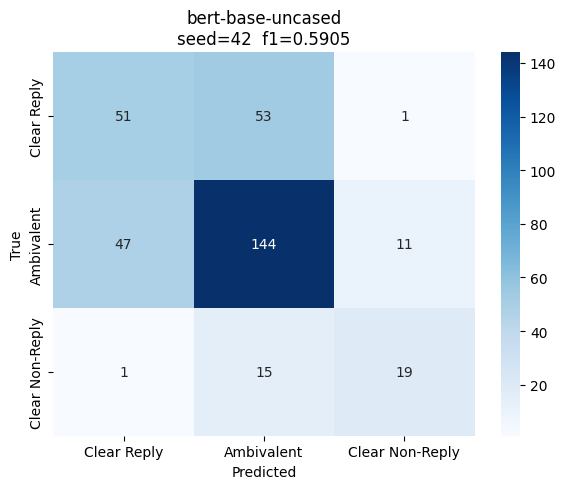

Saved → /kaggle/working/cm_per_model.png


In [43]:
# Cell 6 — Confusion matrix for best run per model (loads val_preds from disk)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

label_names = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

best_per_model = {}
for r in sweep_results:
    model_key = r["cfg"].model_name.split("/")[-1]
    if model_key not in best_per_model or r["val_f1_macro"] > best_per_model[model_key]["val_f1_macro"]:
        best_per_model[model_key] = r

fig, axes = plt.subplots(1, len(best_per_model), figsize=(6 * len(best_per_model), 5))
if len(best_per_model) == 1:
    axes = [axes]

for ax, (model_name, r) in zip(axes, best_per_model.items()):
    val_logits = np.load(Path(r["run_dir"]) / "val_preds.npy")
    val_labels = np.load(Path(r["run_dir"]) / "val_labels.npy")
    preds = val_logits.argmax(axis=1)
    cm = confusion_matrix(val_labels, preds, labels=[0, 1, 2])
    print(f"{model_name} (seed={r['cfg'].seed}, f1={r['val_f1_macro']:.4f}) cm={cm.tolist()}")
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"{model_name}\nseed={r['cfg'].seed}  f1={r['val_f1_macro']:.4f}")

plt.tight_layout()
plt.savefig("/kaggle/working/cm_per_model.png", dpi=150)
plt.show()
print("Saved → /kaggle/working/cm_per_model.png")

In [44]:
# Cell 7 — Generate submission CSV for best run per model (reloads model from disk)
import pandas as pd
from pathlib import Path

label_names_map = {0: "Clear Reply", 1: "Ambivalent", 2: "Clear Non-Reply"}

for model_name, r in best_per_model.items():
    # reload best checkpoint from disk
    reload_model, reload_tok = load_model_and_tokenizer(r["cfg"].model_name, num_labels=NUM_LABELS)
    reload_model.load_state_dict(torch.load(
        Path(r["run_dir"]) / "best_model.pt",
        map_location=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    reload_model.to(device)
    reload_model.eval()

    _, test_df = load_clarity()
    test_df_enc = test_df.copy()
    test_df_enc["label_id"] = 0

    test_ds = tokenize_pairs(test_df_enc, reload_tok, r["cfg"].max_length, r["cfg"].input_fmt)
    test_loader = DataLoader(test_ds, batch_size=r["cfg"].batch_size,
                             sampler=SequentialSampler(test_ds))

    all_preds = []
    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, _ = [b.to(device) for b in batch]
            out = reload_model(input_ids=input_ids, attention_mask=attention_mask)
            all_preds.extend(out.logits.argmax(dim=1).cpu().numpy())

    reload_model.cpu()
    del reload_model, reload_tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    submission = pd.DataFrame({
        "index": test_df["index"] if "index" in test_df.columns else range(len(test_df)),
        "label": [label_names_map[p] for p in all_preds],
    })
    sub_path = f"/kaggle/working/submission_{model_name}.csv"
    submission.to_csv(sub_path, index=False)
    print(f"[{model_name}] → {sub_path}  (run: {r['run_id']}, f1={r['val_f1_macro']:.4f})")
    print(f"  Distribution: {dict(submission['label'].value_counts())}")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please u

RuntimeError: Error(s) in loading state_dict for BertForSequenceClassification:
	Missing key(s) in state_dict: "bert.embeddings.word_embeddings.weight", "bert.embeddings.position_embeddings.weight", "bert.embeddings.token_type_embeddings.weight", "bert.embeddings.LayerNorm.weight", "bert.embeddings.LayerNorm.bias", "bert.encoder.layer.0.attention.self.query.weight", "bert.encoder.layer.0.attention.self.query.bias", "bert.encoder.layer.0.attention.self.key.weight", "bert.encoder.layer.0.attention.self.key.bias", "bert.encoder.layer.0.attention.self.value.weight", "bert.encoder.layer.0.attention.self.value.bias", "bert.encoder.layer.0.attention.output.dense.weight", "bert.encoder.layer.0.attention.output.dense.bias", "bert.encoder.layer.0.attention.output.LayerNorm.weight", "bert.encoder.layer.0.attention.output.LayerNorm.bias", "bert.encoder.layer.0.intermediate.dense.weight", "bert.encoder.layer.0.intermediate.dense.bias", "bert.encoder.layer.0.output.dense.weight", "bert.encoder.layer

In [45]:
# Cell 8 — Download this session's run directories
import shutil, os
from pathlib import Path
from IPython.display import FileLink, display

# zip only the runs from this sweep, not the entire models dir
session_zip_base = "/kaggle/working/session_models"
session_tmp = Path("/kaggle/working/session_models_tmp")
session_tmp.mkdir(exist_ok=True)

for cfg in sweep_configs:
    src = Path(cfg.models_dir) / cfg.run_id
    if src.exists():
        dst = session_tmp / cfg.run_id
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"  included: {cfg.run_id}")
    else:
        print(f"  MISSING:  {cfg.run_id}")

shutil.make_archive(session_zip_base, "zip", str(session_tmp))
shutil.rmtree(session_tmp)

print(f"\nZip created: session_models.zip")
display(FileLink("session_models.zip"))

  included: bert-base-uncased_two_segment_lr2e-05_bs16_ep5_ml256_seed42_aux0.3

Zip created: session_models.zip


/kaggle/working/session_models.zip